# Data Analysis 

In [5]:
import duckdb
from pathlib import Path
import re
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as ts
import statsmodels.graphics.tsaplots as tp
import statsmodels.stats.diagnostic as dg
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings('ignore', category=InterpolationWarning)

DB_PATH = Path("spiff_data.db")
TABLE_NAME = "transformed_data"

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

In [6]:
def distribution_summary(df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = df.columns
    summary_data = []
    for col in numeric_cols:
        summary_data.append({
            "column": col,
            "mean": df[col].mean(),
            "stddev": df[col].std(),
            "skewness": df[col].skew(),
            "excess kurtosis": df[col].kurtosis(),  # excess Kurtosis
            "normality_pvalue": stats.normaltest(df[col].dropna())[1]
        })

    return pd.DataFrame(summary_data)

In [7]:
def get_valid_segments_fixed(series):
    mask = series.notna().to_numpy()
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0] # returns all indexes that satisfies the condition
    ends = np.where(diff == -1)[0]
    return list(zip(starts, ends)) # note that 0-based [start, end)

def get_missing(series):
    mask = series.isna().to_numpy() 
    padded = np.concatenate([[False], mask, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    return list(zip(starts, ends)) # same note that 0-based [start, end)


def temporal_analysis(df: pd.DataFrame) -> pd.DataFrame:
    summary_data = []
    for col in df.columns:
        # calculate the adf/kpss results for all valid intervals longger than 20
        valid_interval = get_valid_segments_fixed(df[col]) 

        adf_result = [ts.adfuller(df[col].iloc[st:ed])[1] for st, ed in valid_interval if (ed - st > 20)]
        kpss_result =  [ts.kpss(df[col].iloc[st:ed])[1] for st, ed in valid_interval if (ed - st > 20)]

        summary_data.append({
            "adf_pvalue": adf_result,
            "adf_stationary":max(adf_result) <0.05, 
            "kpss_pvalue": kpss_result,
            "kpss_stationary":min(kpss_result) > 0.05, 
            "segments": valid_interval
        })

        # plot the ACF for the longest continuous series
        valid_arr = np.array(valid_interval)

        best_idx  = (valid_arr[:, 1] - valid_arr[:, 0]).argmax()
        st, ed = valid_interval[best_idx]
        segment = df[col].iloc[st:ed] 
        returns_centered = segment - segment.mean()
        returns_centered2 = returns_centered.pow(2)

        plot_acf_dir = CHART_DIR / "ACF_Plots"
        Path.mkdir(plot_acf_dir, exist_ok=True)
        fig, ax = plt.subplots(1, 3, figsize=(4*3, 4), sharex=True)
        name = col.split('_')[0]
        tp.plot_acf(returns_centered, lags=20, ax=ax[0], markersize=4, title=f"ACF of {name}")
        tp.plot_pacf(returns_centered, lags=20, ax=ax[1], markersize=4, method="ywm", title=f"PACF of {name}")
        tp.plot_acf(returns_centered2, lags=20, ax=ax[2], markersize=4, title=f"ACF of {name}_squared")
        # tp.plot_pacf(returns_centered2, lags=20, ax=ax[3], markersize=4, method="ywm", title=f"PACF of {name}")

        ax[0].set_xlabel("Lag")
        ax[1].set_xlabel("Lag")
        ax[2].set_xlabel("Lag")
        # ax[3].set_xlabel("Lag")

        ax[0].set_ylabel("ACF")
        ax[1].set_ylabel("PACF")
        ax[2].set_ylabel("ACF")
        # ax[3].set_ylabel("PACF")

        plt.tight_layout()
        # plt.savefig(plot_acf_dir / f"(P)ACF_{col}.jpg", dpi=180)
        # plt.close()

        lb_p = dg.acorr_ljungbox(
            returns_centered,
            lags=20,
            boxpierce=False,
            model_df=0,
            period=None,
            return_df=True,
            auto_lag=False
        )["lb_pvalue"]
        lb2_p = dg.acorr_ljungbox(
            returns_centered2,
            lags=20,
            boxpierce=False,
            model_df=0,
            period=None,
            return_df=True,
            auto_lag=False
        )["lb_pvalue"]

        summary_data[-1].update({
            "lb_pvalue": lb_p.min(),
            "lb2_pvalue": lb2_p.min(),
        })

    return pd.DataFrame(summary_data, index=df.columns)

In [8]:
def correlation_analysis(df: pd.DataFrame, min_periods=30) -> pd.DataFrame:
    # Correlation Matrix
    numeric_cols = df.columns
    correlation_matrix = df[numeric_cols].corr(min_periods=30)

    return correlation_matrix

In [9]:
with duckdb.connect(DB_PATH) as conn:
    cols = conn.execute("DESCRIBE transformed_data").df()["column_name"].tolist()
    val_cols = [c for c in cols if "logreturn" in c]
    df = conn.execute(f"SELECT day, {', '.join(val_cols)} FROM {TABLE_NAME}").df()
print(df.describe())
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
df.head()

              day  gurkor_logreturn  guitars_logreturn  slingshots_logreturn  \
count  5455.00000       5204.000000        5204.000000           5204.000000   
mean   2729.00000          0.000067           0.000096              0.000086   
std    1574.86719          0.091184           0.101913              0.108967   
min       2.00000         -2.203112          -2.544536             -2.683994   
25%    1365.50000         -0.000869          -0.002873             -0.002842   
50%    2729.00000          0.000000           0.000234              0.000200   
75%    4092.50000          0.001061           0.003249              0.003259   
max    5456.00000          2.199571           2.548147              2.686583   

       stocks_logreturn  sugar_logreturn  water_logreturn  \
count       5204.000000      5204.000000      5204.000000   
mean          -0.000036        -0.000010         0.000066   
std            0.096276         0.112960         0.099489   
min           -2.342907        -2.7

,day,gurkor_logreturn,guitars_logreturn,slingshots_logreturn,stocks_logreturn,sugar_logreturn,water_logreturn,tranquillity_logreturn
0,2,0.002461,0.007516,-0.004691,0.000846,0.004010,0.000420,0.001422
1,3,-0.001475,-0.000523,0.000566,0.005976,-0.002502,-0.000280,0.005815
2,4,-0.000863,-0.002494,-0.004165,0.001059,-0.006318,0.000419,-0.002106
3,5,-0.002226,0.001446,0.000760,0.000477,0.002032,0.000466,0.001931
4,6,0.001485,0.004957,0.001895,-0.001778,0.000000,0.000605,-0.001755


We first assess the data by identifying the structure and distribution of missing values. <br>
- Initial diagnostics reveal 251 missing observations (~4.6%) per asset. <br>
- To understand the distribution, we computed the Rolling Missing Ratio. As illustrated in the visualization, the missing data does not occur randomly but concentrated, particularly in a large block at the end of the series, i.e., a minor cluster in the early stage (a single missing block of size 51 within indices 0–1500) and a major contiguous block at the end (a single missing block of size 200 spanning indices 5255–5455). <br>

In subsequent analyses, we truncate the trailing missing block and explicitly handle internal missing values using test-specific procedures.

,missing_count,missing_ratio,missing_interval
gurkor_logreturn,251,0.046013,"[(197, 248), (5255, 5455)]"
guitars_logreturn,251,0.046013,"[(397, 448), (5255, 5455)]"
slingshots_logreturn,251,0.046013,"[(597, 648), (5255, 5455)]"
stocks_logreturn,251,0.046013,"[(797, 848), (5255, 5455)]"
sugar_logreturn,251,0.046013,"[(997, 1048), (5255, 5455)]"
water_logreturn,251,0.046013,"[(1197, 1248), (5255, 5455)]"
tranquillity_logreturn,251,0.046013,"[(1397, 1448), (5255, 5455)]"


Missing values by column:


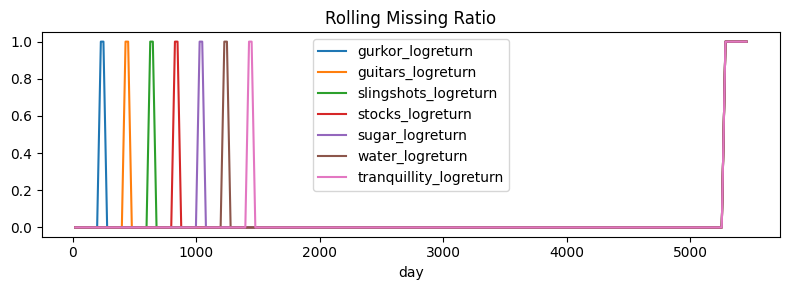

In [10]:
# Handling missing values
df1 = df.set_index("day")

# Mssing value analysis
missing_counts = df1.isna().sum().sort_values(ascending=False)
segments = pd.Series([get_missing(df1[col]) for col in df1.columns], index=missing_counts.index)
display(pd.concat([missing_counts, missing_counts/len(df1), segments], axis=1, keys=["missing_count", "missing_ratio","missing_interval"]))
print("Missing values by column:")

plt.figure(figsize=(8, 3))
for col in val_cols:
    df1[col].isna().rolling(30, min_periods=20).mean().plot(label=col) # the percentage of missing values within the window, spotting trends in data loss
plt.title(f"Rolling Missing Ratio")
plt.legend()
plt.tight_layout()
plt.show()

df_trunc = df1.loc[:5255]
# df_trunc.isna().sum().sort_values(ascending=False)

#### Data Preprocessing & Distributional Characteristics

A direct visualization reveals the presence of isolated sharp spikes that disproportionately affect the scale of the series, thereby obscuring the underlying patterns. These extreme observations are treated as potential outliers and are removed in subsequent preprocessing to ensure more reliable analysis. 

To achieve this, we employ a rolling median filter, which is less sensitive to outliers while preserving local temporal structure. Specifically, a sliding window of 150 observations (approximately 3% of the series) is used, together with a threshold of 5 median absolute deviations (MAD).

Given the presence of a contiguous block of missing values, a segment-based approach is adopted to ensure that statistical estimators are computed only within continuous observation intervals. For sufficiently long segments, rolling median and MAD estimators (window size = 150, minimum valid observations = 100) are applied to capture local dynamics. For shorter segments, a global MAD-based criterion is used instead to ensure statistical stability. Detected outliers are removed and treated as missing values, followed by limited linear interpolation (maximum gap of 2 observations) to prevent excessive smoothing.

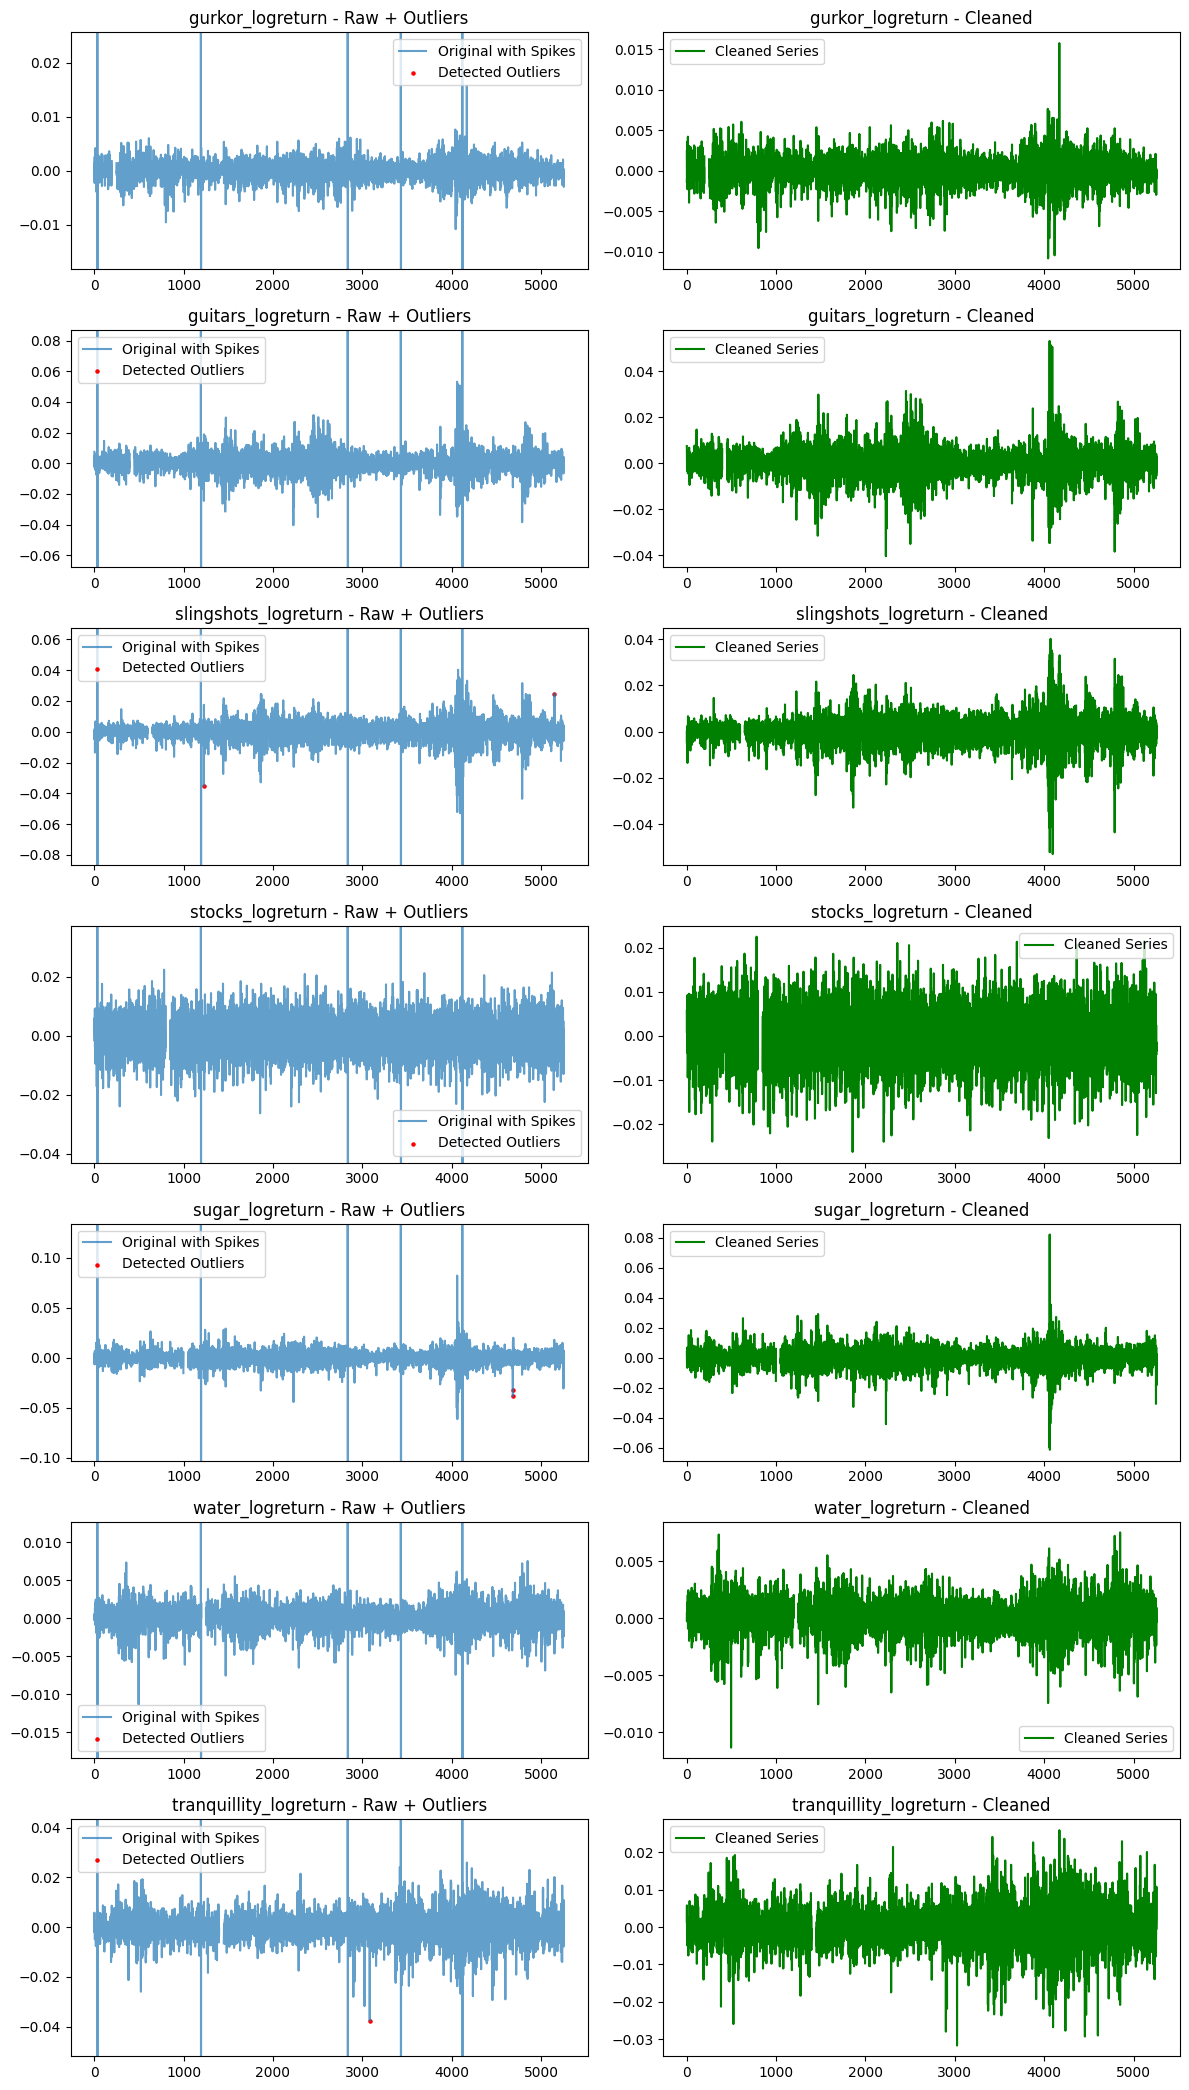

Distributional analysis before cleaning:


,column,mean,stddev,skewness,excess kurtosis,normality_pvalue,normality_flag
0,gurkor_logreturn,0.000067,0.091193,-0.014373,521.682096,0.0,False
1,guitars_logreturn,0.000096,0.101923,-0.098872,520.024917,0.0,False
2,slingshots_logreturn,0.000085,0.108977,0.016094,519.535086,0.0,False
3,stocks_logreturn,-0.000035,0.096285,-0.069137,519.125860,0.0,False
4,sugar_logreturn,-0.000008,0.112971,-0.062770,519.413117,0.0,False
5,water_logreturn,0.000066,0.099499,0.006196,520.430079,0.0,False
6,tranquillity_logreturn,0.000031,0.086467,-0.040152,522.418558,0.0,False


Distributional analysis after cleaning:


,column,mean,stddev,skewness,excess kurtosis,normality_pvalue,normality_flag
0,gurkor_logreturn,0.000068,0.001712,-0.148034,3.522932,2.541949e-98,False
1,guitars_logreturn,0.000103,0.006456,-0.035129,5.567901,8.153760e-137,False
2,slingshots_logreturn,0.000081,0.006375,-0.428366,6.376150,2.744548e-182,False
3,stocks_logreturn,-0.000037,0.006494,-0.127317,0.075295,5.011101e-04,False
4,sugar_logreturn,0.000011,0.006561,-0.186968,10.709511,1.548806e-213,False
5,water_logreturn,0.000066,0.001526,-0.260689,2.253579,2.204009e-73,False
6,tranquillity_logreturn,0.000048,0.005445,-0.214022,2.636951,4.032295e-80,False


In [11]:
if "df_trunc" not in globals() or "val_cols" not in globals():
    raise RuntimeError("Run the data loading cell first.")

# Handling extreme values
df_clean = df_trunc.copy()

def clean_spikes_rolling(s, window=150, tolerance=8):
    """"
    clean spikes in a pandas Series using a rolling median and median absolute deviation(MAD) approach. 
    It identifies outliers based on the deviation from the rolling median, scaled by the MAD, 
    and replaces them with NaN before interpolating to fill the gaps.
    """
    rolling_median = s.rolling(window=window, center=True, min_periods = window).median()
    # requires full-sized window
    def get_mad(x):
        m = np.nanmedian(x)
        return np.nanmedian(np.abs(x - m))
        
    rolling_mad = s.rolling(window=window, center=True, min_periods=window).apply(get_mad)
    is_outlier = (s - rolling_median).abs() > tolerance * (1.4826 * rolling_mad)

    s_clean = s.copy()   
    # the marginal part contains nan due to inadequate data points for computation
    is_outlier_global = pd.Series(False, index=s.index)
    edge = window//2
    # left boundary
    left = s.iloc[:edge] # due to min_periods
    left_clean, left_out = clean_spikes_global(left)

    is_outlier_global.iloc[:edge] = left_out
    # right boundary
    right = s.iloc[-edge:]
    right_clean, right_out = clean_spikes_global(right)
    is_outlier_global.iloc[-edge:] = right_out
    
    s_clean.iloc[:edge] = left_clean
    s_clean.iloc[-edge:] = right_clean

    # NaN > NaN -> False in is_outlier, not affected in the rolling region
    s_clean[is_outlier] = np.nan
    # Interpolate to fill the NaN values created by outlier removal with a limit of 2 to prevent over-smoothing based on global MAD filtering
    s_clean = s_clean.interpolate(method='linear', limit=2) 
    
    is_outlier_global |= is_outlier
    return s_clean, is_outlier_global

def clean_spikes_global(s, tolerance=8):        
    # global MAD
    global_median = np.nanmedian(s)
    deviation = np.nanmedian(np.abs(s - global_median))
    is_outlier = (s - global_median).abs() > tolerance * (1.4826 * deviation)

    s_clean = s.copy()
    s_clean[is_outlier] = np.nan

    # Interpolate to fill the NaN values created by outlier removal with a limit of 2 to prevent over-smoothing
    s_clean = s_clean.interpolate(method='linear', limit=2) 

    return s_clean, is_outlier

ncols = 2
nrows = len(val_cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
axes = axes.flatten() 
for i, col in enumerate(val_cols):
    row = int(i//2)
    ax0 = axes[2*i]
    ax1 = axes[2*i+1]

    all_outliers = pd.Series(False, index=df_clean[col].index)
    col_idx = df_clean.columns.get_loc(col)
    segments = get_valid_segments_fixed(df_trunc[col])
    for st, ed in segments:
        if ed - st >= 225: # 1.5 window_size
            df_clean.iloc[st:ed, col_idx], outliers = clean_spikes_rolling(df_trunc[col][st:ed])
        else:
            df_clean.iloc[st:ed, col_idx], outliers = clean_spikes_global(df_trunc[col][st:ed])
        all_outliers.iloc[st:ed] = outliers
    ax0.plot(df_trunc.index, df_trunc[col], label='Original with Spikes', alpha=0.7)
    ax0.scatter(df_trunc.index[all_outliers], df_trunc.loc[all_outliers, col], color='red', label='Detected Outliers', s=5)
    current_ylim = ax0.get_ylim()
    ax0.set_title(f"{col} - Raw + Outliers")
    ax0.legend()

    ax1.plot(df_clean.index, df_clean[col], label='Cleaned Series', color='green')
    ax1.set_title(f"{col} - Cleaned")
    ax1.legend()
    
    # truncate the plot for raw series
    ymin, ymax = ax1.get_ylim()
    ax0.set_ylim(ymin * 1.5, ymax * 1.5)

plt.tight_layout()
plt.show()

dis_summary = distribution_summary(df_trunc)
dis_summary["normality_flag"] = dis_summary["normality_pvalue"] > 0.05
print("Distributional analysis before cleaning:")
display(dis_summary)
print("Distributional analysis after cleaning:")
dis_summary_clean = distribution_summary(df_clean)
dis_summary_clean["normality_flag"] = dis_summary_clean["normality_pvalue"] > 0.05
display(dis_summary_clean)

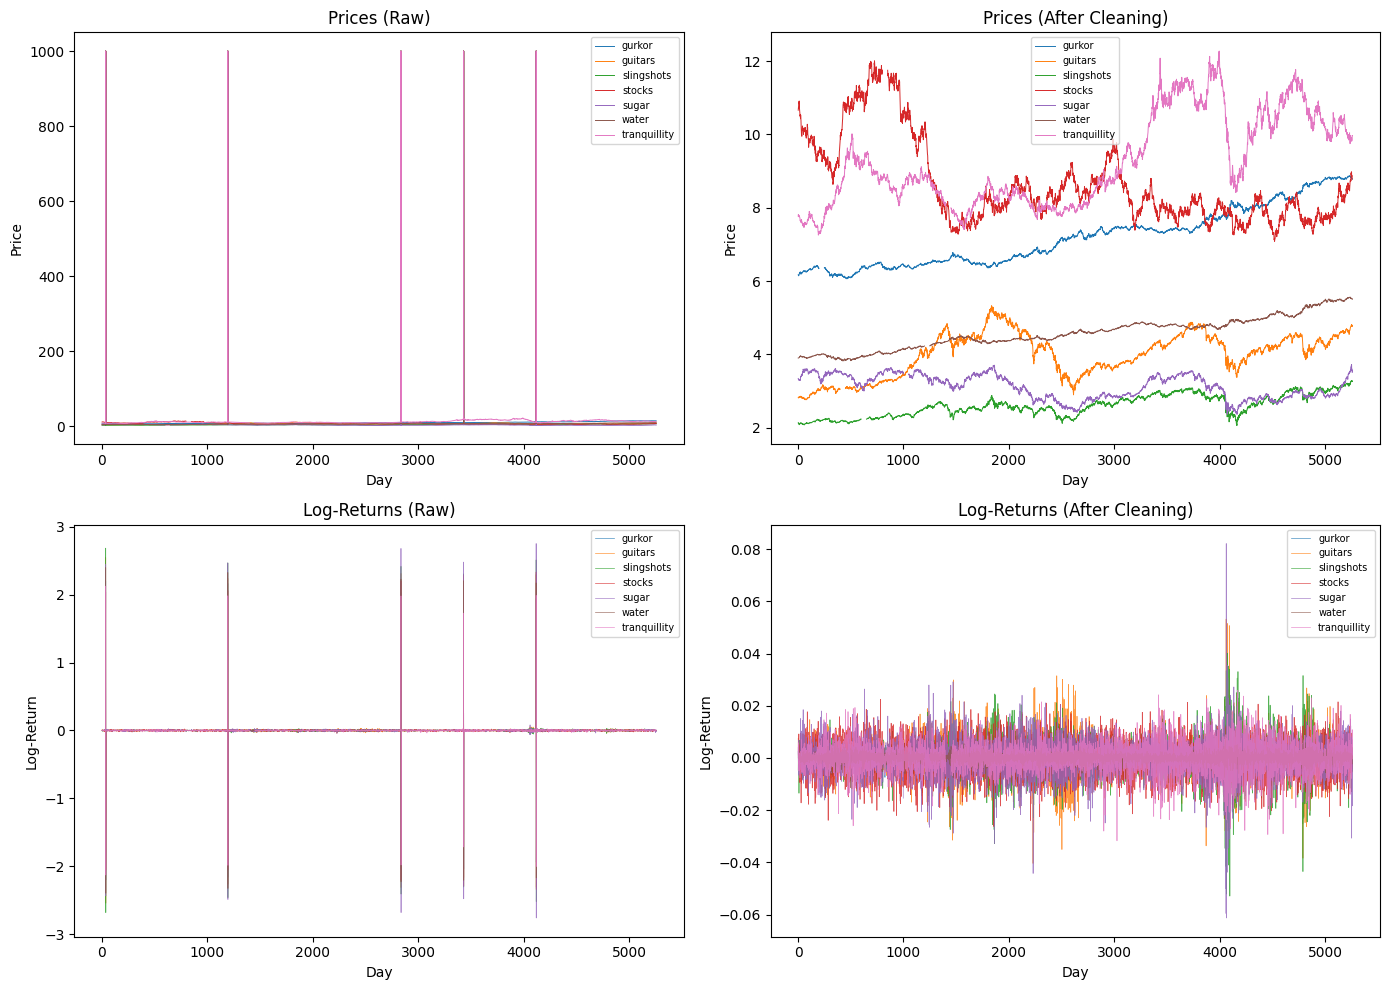

In [12]:
# Load raw prices and reconstruct cleaned prices from cleaned log-returns
with duckdb.connect(DB_PATH) as conn:
    price_cols = [c for c in conn.execute("DESCRIBE spiff").df()["column_name"].tolist() if c != "day"]
    df_prices = conn.execute(f"SELECT day, {', '.join(price_cols)} FROM spiff").df().set_index("day")

# Reconstruct cleaned prices: P_t = P_0 * exp(cumsum(cleaned_logreturns))
df_prices_clean = pd.DataFrame(index=df_clean.index)
for col in val_cols:
    asset = col.replace("_logreturn", "")
    if asset in df_prices.columns:
        p0 = df_prices[asset].iloc[0]
        df_prices_clean[asset] = p0 * np.exp(df_clean[col].cumsum())

# Also build raw prices aligned to df1 index for comparison
df_prices_raw = df_prices.reindex(df1.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Raw prices
ax = axes[0, 0]
for col in price_cols:
    ax.plot(df_prices_raw.index, df_prices_raw[col], linewidth=0.7, label=col)
ax.set_title("Prices (Raw)")
ax.set_xlabel("Day")
ax.set_ylabel("Price")
ax.legend(fontsize=7)

# Top-right: Cleaned prices
ax = axes[0, 1]
for col in df_prices_clean.columns:
    ax.plot(df_prices_clean.index, df_prices_clean[col], linewidth=0.7, label=col)
ax.set_title("Prices (After Cleaning)")
ax.set_xlabel("Day")
ax.set_ylabel("Price")
ax.legend(fontsize=7)

# Bottom-left: Raw log-returns
ax = axes[1, 0]
for col in val_cols:
    ax.plot(df1.index, df1[col], linewidth=0.5, alpha=0.8, label=col.replace("_logreturn", ""))
ax.set_title("Log-Returns (Raw)")
ax.set_xlabel("Day")
ax.set_ylabel("Log-Return")
ax.legend(fontsize=7)

# Bottom-right: Cleaned log-returns
ax = axes[1, 1]
for col in val_cols:
    ax.plot(df_clean.index, df_clean[col], linewidth=0.5, alpha=0.8, label=col.replace("_logreturn", ""))
ax.set_title("Log-Returns (After Cleaning)")
ax.set_xlabel("Day")
ax.set_ylabel("Log-Return")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

Here, we present distributional analysis comparing the dataset of log-returns before and after the data cleaning process. 
- **Bias correction(Mean):** The mean values across most assets remained nearly identical to their raw state, which confirms that the cleaning process is unbiased, removing local noise without shifting the long-term expected returns. Note that the most critical shift occurred in "sugar_logreturn", where the mean flipped from negative to positive. This indicates the removal of extreme negative outliers that were distorting the asset's true performance.

- **Volatility Stabilization(Stddev):** A universal reduction in standard deviation across all assets confirms the effective suppression of non-representative variance-inflating noise.

- **Symmetry(Skewness):** The skewness across most assets shifts systematically toward more negative values after cleaning. In several cases (e.g., slingshots, water), the distribution moves from near-symmetric or slightly positive skew to clearly negative skew. In other assets that were already negatively skewed (e.g., stocks, sugar, tranquillity), the skewness becomes more pronounced in the same direction. A smaller subset shows attenuation of negative skew (e.g., guitar), where the value moves closer to zero. Overall, the transformation is heterogeneous across assets but directionally concentrated toward increased left-skewness in most series, indicating that the cleaned distributions exhibit stronger asymmetry in the negative tail compared to the raw data. These negative skewness values reflect an asymmetric risk profile where extreme losses dominate the distribution’s left tail, indicating higher downside risk than upside potential.

- **Normalization of Tails(Excess Kurtosis):** High kurtosis signifies "heavy tails" or frequent extreme outliers. The data cleaning process effectively addressed the excess kurtosis across the portfolio by suppressing variance-inflating "spikes" while preserving fundamental distributional characteristics. 
The resulting excess kurtosis values indicate substantial heterogeneity in tail behavior across assets. While stocks exhibit near-Gaussian behavior, most other assets display pronounced heavy-tailed distributions, with sugar showing extremely high kurtosis. This suggests that extreme observations play a dominant role in shaping the distributional characteristics of most assets, implying that risk is largely concentrated in infrequent but large deviations rather than in regular fluctuations.

We provide both the P-value and a Normality Flag to assess the distributional nature of the cleaned data. All assets reject the null hypothesis of normality at the 5% level, indicating significant deviations from Gaussianity. However, the strength of deviation varies across assets, with stock exhibiting a comparatively weaker departure.

**Normality**<br>
We begin with a histogram as an initial visual inspection to gauge the distributional shape of the log-returns, and further use quantile–quantile (Q–Q) plots to assess distributional normality and residual tail behavior by comparing empirical quantiles against theoretical normal quantiles. This provides a visual diagnostic of whether remaining extreme observations reflect systematic deviations from Gaussianity or isolated shocks.

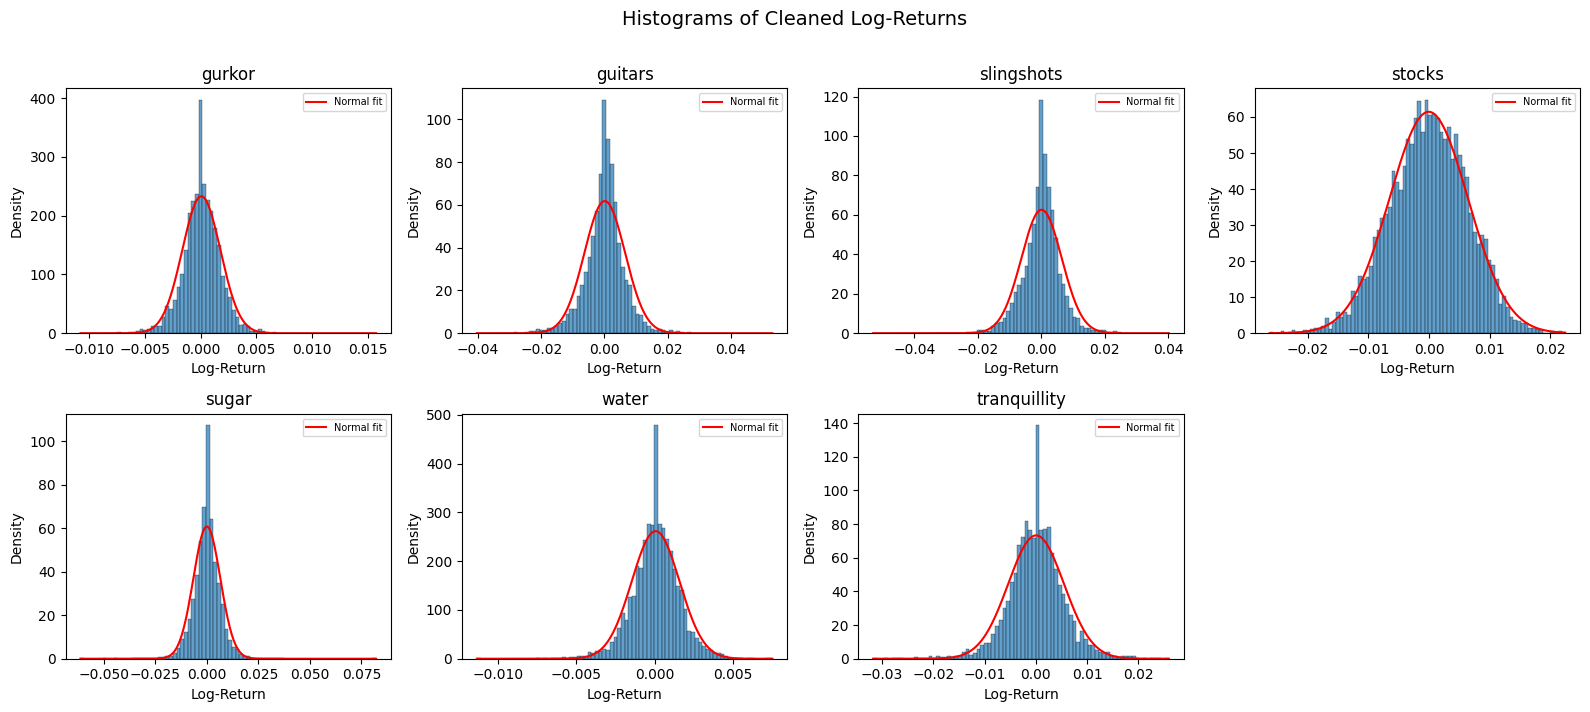

In [13]:
# Histograms of cleaned log-returns with normal overlay
nrows = 2
ncols = len(val_cols) // 2 + (len(val_cols) % 2 != 0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(val_cols):
    ax = axes[i]
    name = col.replace("_logreturn", "")
    data = df_clean[col].dropna()

    ax.hist(data, bins=80, density=True, alpha=0.7, edgecolor="black", linewidth=0.3)

    # Normal distribution overlay
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5, label="Normal fit")

    ax.set_title(f"{name}")
    ax.set_xlabel("Log-Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Histograms of Cleaned Log-Returns", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

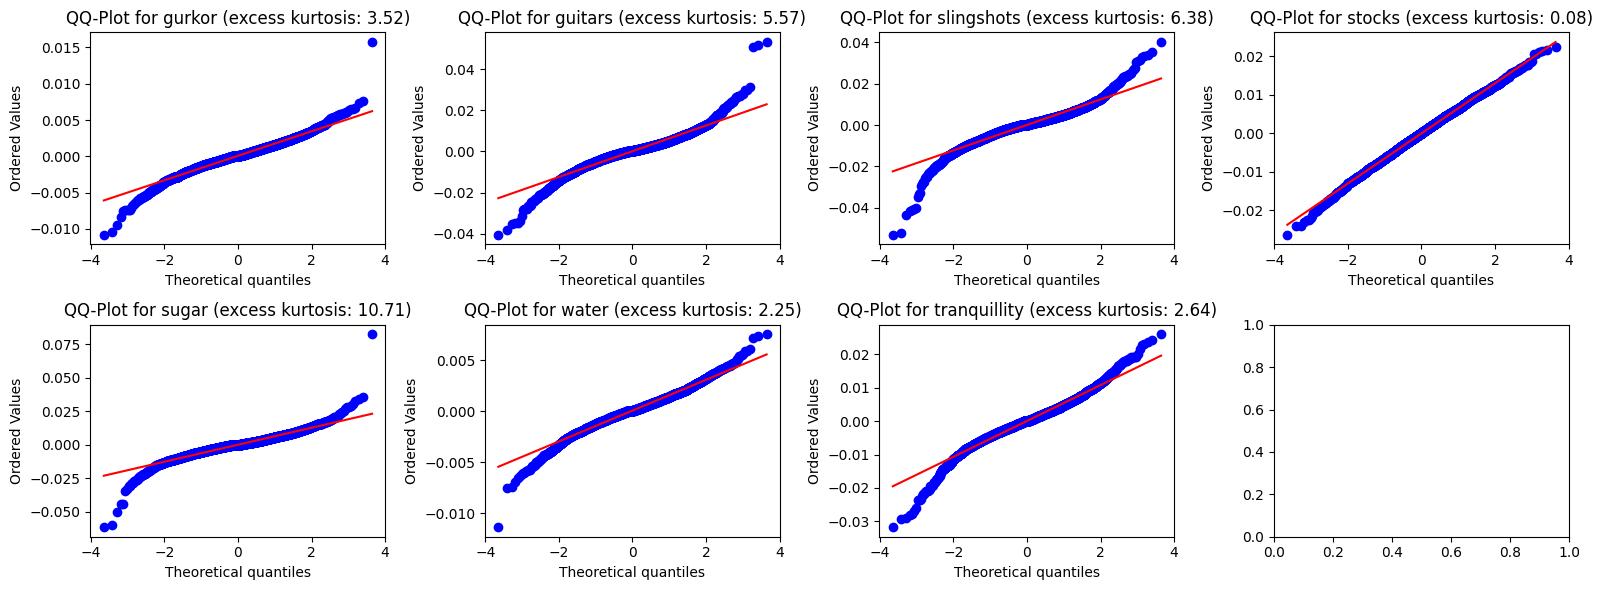

In [14]:
if "dis_summary_clean" not in globals() or "df_clean" not in globals():
    raise RuntimeError("Run distribution and data loading cells first.")

target_cols = dis_summary_clean[dis_summary_clean["excess kurtosis"] > 0]["column"].tolist()
QQ_DIR = Path("QQ_Plots")
Path.mkdir(CHART_DIR / QQ_DIR, exist_ok=True)

nrows = 2
ncols = len(target_cols)//2 +(len(target_cols)%2 !=0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()
for i, col in enumerate(target_cols):
    name = col.split('_')[0]
    kurt_val = dis_summary_clean.loc[dis_summary_clean["column"] == col, "excess kurtosis"].values[0]
    stats.probplot(df_clean[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"QQ-Plot for {name} (excess kurtosis: {kurt_val:.2f})")
fig.tight_layout()
plt.show()

**Deviation from normality and tail behaviour**

The Q-Q plots reveal heterogeneity in both the degree and structure of non-normality across all assets.
- stocks (0.08) are near-Gaussian with only marginal bilateral tail deviations. 
- water(2.25) fits the reference line closely throughout, with mild and gradual tail departures. 
- tranquillity and gurkor (2.64, 3.52), despite moderate kurtosis, both show emerging systematic left-tail departure while the right tail remains limited, suggesting left-tail thickness is beginning to be structural rather than purely event-driven.
- guitars and slingshots (5.57, 6.38) exhibit clearly structural bilateral heavy tails with more pronounced central deviation,and the left tail more severe in both cases, consistent with leverage effects common in commodity markets. 
- sugar (10.71) shares similarly severe and systematic left-tail departure as slingshots, while its central and right portions track the reference line relatively well.

**Isolated extreme observations**

Several assets exhibit isolated extreme observations that deviate from the otherwise smooth tail behavior in the QQ-plot, indicating the presence of discrete extreme realizations beyond the general heavy-tailed pattern. 
- water has 1 isolated left-tail extreme; 
- gurkor has 1 isolated right-tail extremes; 
- guitars has 3 isolated right-tail extremes superimposed on its structural heavy tail; 
- sugar has 1 isolated right-tail extreme. 

Given the deliberately conservative rolling MAD-based cleaning procedure (with an effective threshold around $8\sigma$), these points are highly unlikely to be artifacts of data errors. Instead, they most likely reflect genuine extreme realizations of the underlying return process. 

While the QQ-plot itself does not retain temporal information, inspection of the raw time series reveals a pronounced synchronous spike at approximately 4000 across most assets, suggesting that at least some of these extreme observations may be associated with a common underlying shock, potentially reflecting a shared market disturbance.

#### Temporal Properties & Stationarity Analysis

To preserve the integrity of the temporal structure, we avoid naive deletion or concatenation, which would artificially treat distant observations as adjacent and bias our inference. Instead, the series is partitioned into discrete, continuous segments. Specifically, we employ a dual-track validation strategy:
1. We conduct analysis across all continuous segments to verify the consistency of statistical patterns throughout the entire observation period, such as the Augmented Dickey–Fuller (ADF) and KPSS tests. 
2. For depth-dependent modeling (e.g., estimating long-term temporal dependencies), we utilize only the largest continuous segment. This ensures that the estimated dynamics are derived from a high-fidelity sequence, free from the biases typically induced by missing intervals or improper joins.

While the QQ-Plots provides the "static" profile of the data, which highlights the presence of fat tails in most of the datasets, we further compute the 30-day rolling volatility to analyze the temporal structure underlying the observed fat tails — specifically, whether they arise from volatility clustering, structural regime shifts, or both. By isolating the largest continuous data segment, we ensure that the rolling window remains free from interpolation artifacts, providing a cleaner narrative of the asset’s historical stress periods. 

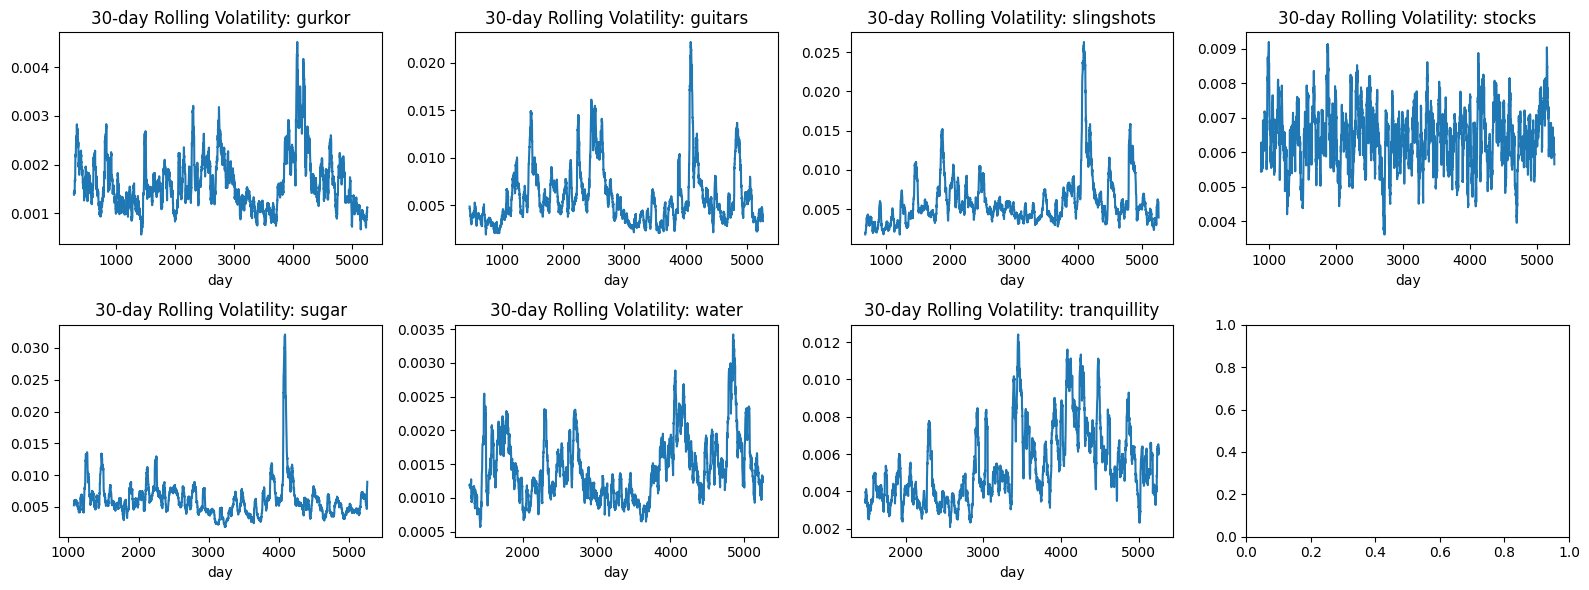

In [15]:
if "dis_summary_clean" not in globals() or "df_clean" not in globals() or "target_cols" not in globals():
    raise RuntimeError("Run distribution and data loading cells first.")

ROLLING_DIR = Path("Rolling_Volatility")
Path.mkdir(CHART_DIR / ROLLING_DIR, exist_ok=True)

nrows = 2
ncols = len(target_cols)//2 +(len(target_cols)%2 !=0)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

axes = axes.flatten()
for i, col in enumerate(target_cols):
    name = col.split('_')[0]

    intervals = get_valid_segments_fixed(df_clean[col])
    st, ed = max(intervals, key=lambda x: df_clean[col].loc[x[0]:x[1]].shape[0])

    largest_segment = df_clean[col].loc[st:ed]
    largest_segment.rolling(30).std().plot(title=f"30-day Rolling Volatility: {name}", ax=axes[i])
fig.tight_layout()
plt.show()

Based on the provided visualizations, 
1. most assets, such as guitars, slingshots, sugar, and gurkor, display classic volatility clustering: extended calm periods punctuated by sharp, transient spikes that gradually decay. This persistence of shocks is consistent with ARCH/GARCH dynamics and partially explains the fat tails documented in the Q-Q plots.

2. tranquillity and water provide the clearest evidence of structural regime shifts. Tranquillity's volatility floor rises markedly after ~day 3500 and remains elevated, indicating a persistent change in unconditional variance rather than a temporary shock. Water similarly shows a sustained increase in baseline volatility from ~day 3500 onward. For these assets, fat tails over the full sample likely reflect the mixing of two distinct volatility regimes, which standard GARCH may not fully capture without incorporating regime-switching components.

3. a synchronised volatility spike around day 4000 is visible across all assets, consistent with a common systemic shock. For clustering-dominated assets this spike is transient; for tranquillity and water it appears to have catalysed the transition to a persistently higher volatility regime.

The QQ-plots establish the presence of leptokurtosis (“fat tails”), while the rolling volatility highlights periods of elevated variability over time and helps identify whether this is driven by volatility clustering or structural regime shifts, as well as when these effects occur. The ACF and PACF, computed on the largest continuous segment, characterize the local dependence structure within a relatively stable regime, reducing distortions from structural breaks.

**Dependency Identification:** The ACF captures total serial dependence (direct and indirect) across lags, while the PACF isolates the direct effect of each lag after removing intermediate effects. Together, they allow us to identify significant short-term dependencies and potential Autoregressive (AR) models, guiding AR and MA order selection for mean modelling.

**Linear vs. Non-linear Dynamics:** ACF/PACF of log-returns reveal the linear dependence structure and any short-term mean predictability, while ACF/PACF of squared log-returns capture the persistence of second-moment dependence. This is the key diagnostic for ARCH/GARCH effects and volatility memory.

Addtionally, we also apply both the Augmented Dickey–Fuller (ADF) and KPSS tests in a complementary manner to each continuous segment, exploiting their opposing null hypotheses for robust inference. Consistent results of ADF ($p \lt 0.05$) and KPSS ($p>0.05$) across segments confirm that log-returns are stationary and free from unit roots or deterministic trends, validating the use of ARMA-GARCH frameworks.

Temporal analysis:


,adf_pvalue,adf_stationary,kpss_pvalue,kpss_stationary,segments,lb_pvalue,lb2_pvalue
gurkor_logreturn,"['9.33e-25', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 197), (248, 5254)]",0.003077,0.000000
guitars_logreturn,"['0.00e+00', '1.19e-20']",True,"['0.1000', '0.1000']",True,"[(0, 397), (448, 5254)]",0.000566,0.000000
slingshots_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 597), (648, 5254)]",0.000000,0.000000
stocks_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 797), (848, 5254)]",0.673332,0.340663
sugar_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 997), (1048, 5254)]",0.000000,0.000000
water_logreturn,"['0.00e+00', '0.00e+00']",True,"['0.1000', '0.1000']",True,"[(0, 1197), (1248, 5254)]",0.003943,0.000000
tranquillity_logreturn,"['3.88e-11', '0.00e+00']",True,"['0.0860', '0.1000']",True,"[(0, 1397), (1448, 5254)]",0.049908,0.000000


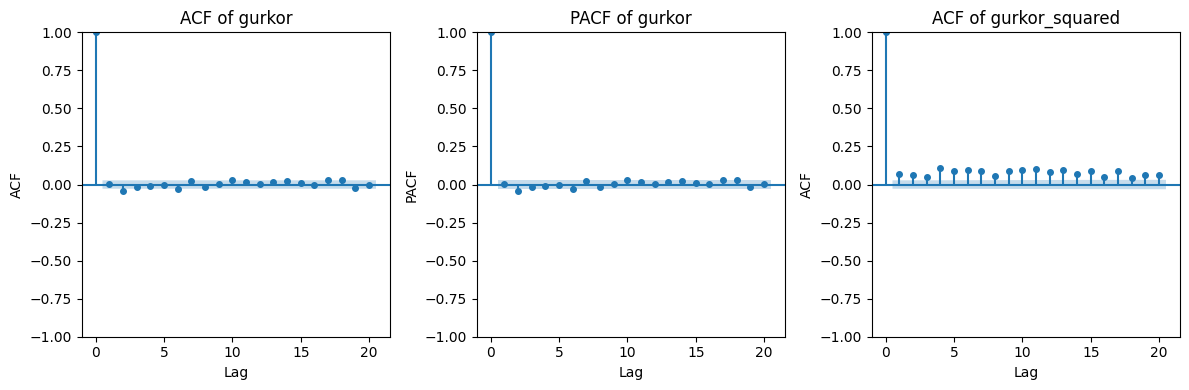

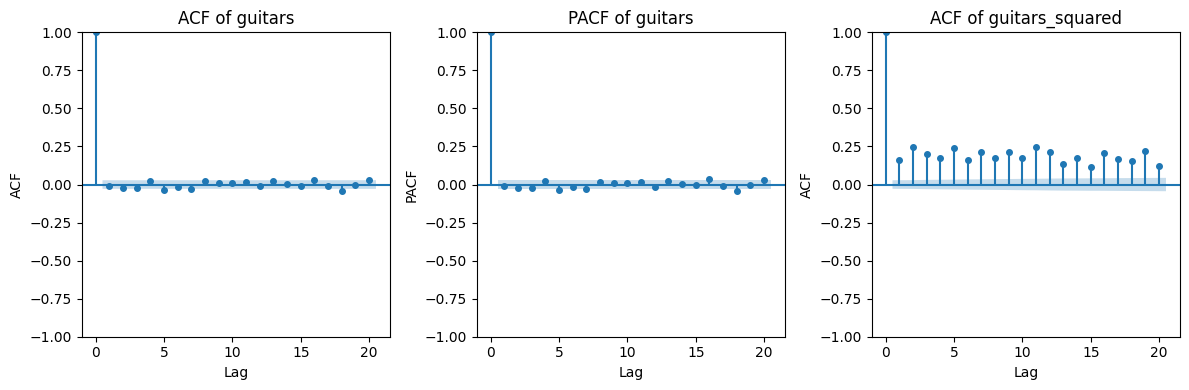

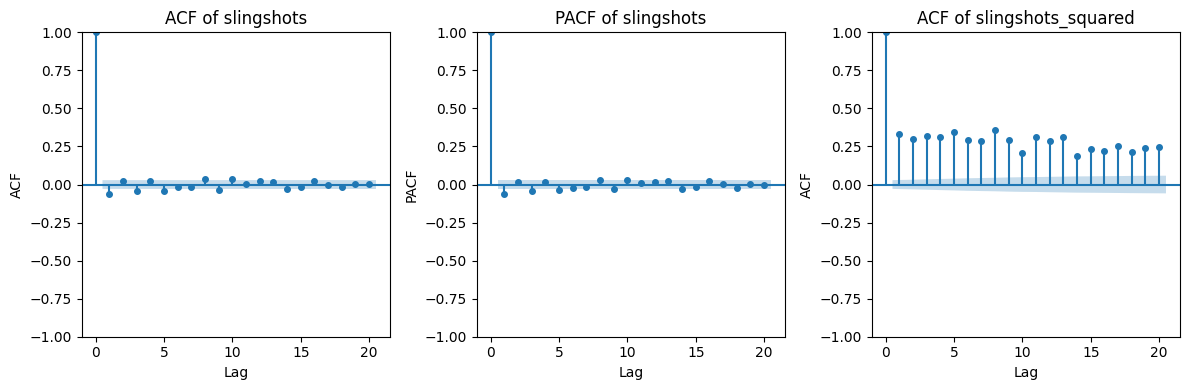

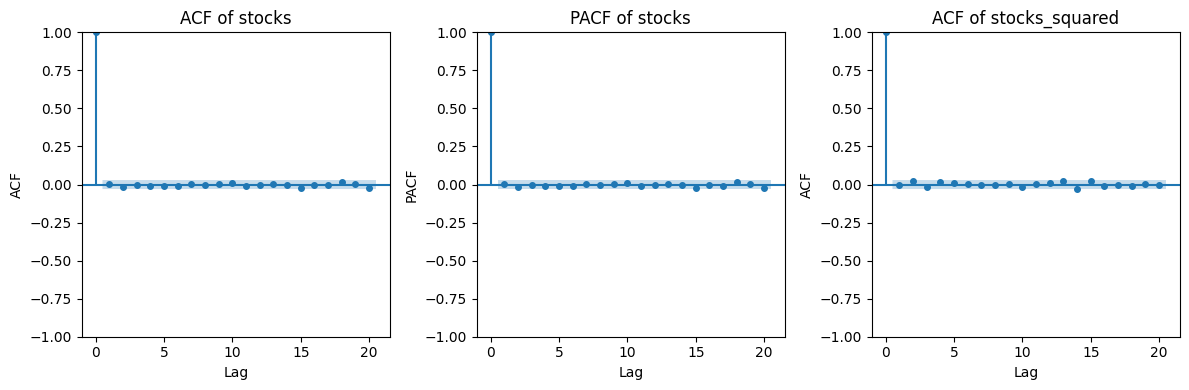

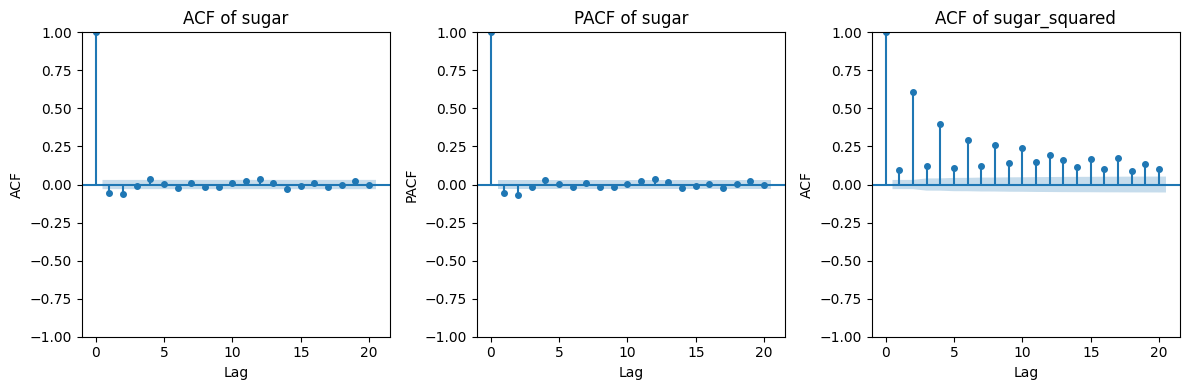

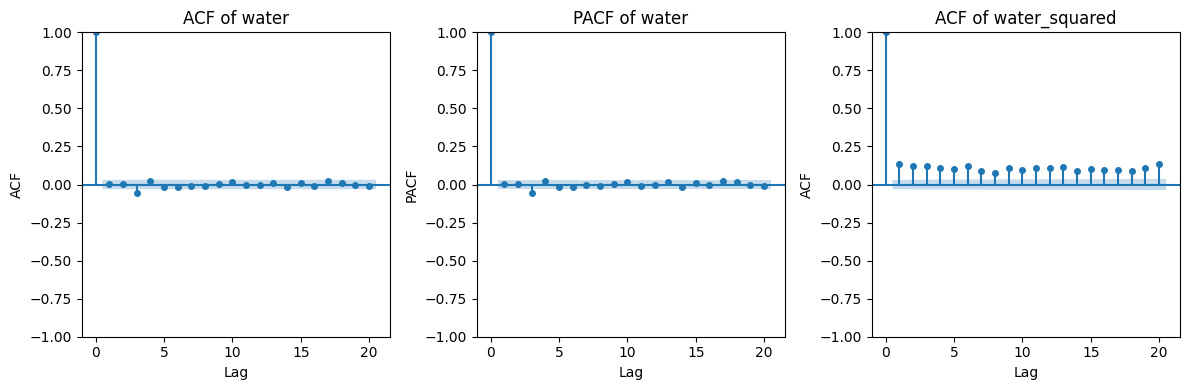

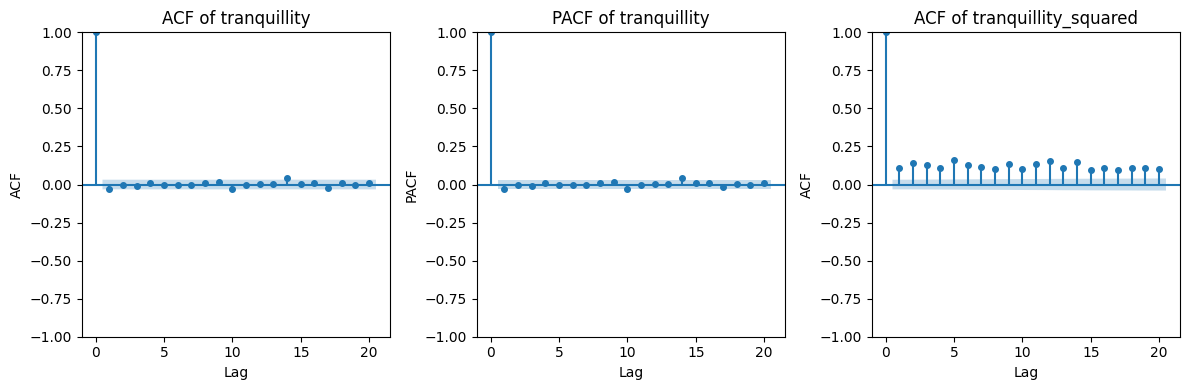

In [16]:
if "df_clean" not in globals():
    raise RuntimeError("Run the data loading cell first.")

temporal_summary = temporal_analysis(df_clean)
print("Temporal analysis:")
display(temporal_summary.style.format({
    "adf_pvalue": lambda x: [f"{i:.2e}" for i in x] if isinstance(x, list) else x,
    "kpss_pvalue": lambda x: [f"{i:.4f}" for i in x] if isinstance(x, list) else x
}))

Significance is assessed at the 95% confidence level. For cleaned log-returns, we expect most lags to be insignificant, consistent with a white noise mean process, while squared returns are expected to show significant autocorrelation, motivating GARCH modelling.

,gurkor_logreturn,guitars_logreturn,slingshots_logreturn,stocks_logreturn,sugar_logreturn,water_logreturn,tranquillity_logreturn
gurkor_logreturn,1.000000,-0.241018,-0.214801,-0.042334,-0.065731,0.573106,-0.139461
guitars_logreturn,-0.241018,1.000000,0.524931,0.017060,0.208544,-0.225849,0.224491
slingshots_logreturn,-0.214801,0.524931,1.000000,0.015004,0.116743,-0.198784,0.181833
stocks_logreturn,-0.042334,0.017060,0.015004,1.000000,-0.016174,-0.041500,0.010034
sugar_logreturn,-0.065731,0.208544,0.116743,-0.016174,1.000000,-0.068948,0.125521
water_logreturn,0.573106,-0.225849,-0.198784,-0.041500,-0.068948,1.000000,-0.157561
tranquillity_logreturn,-0.139461,0.224491,0.181833,0.010034,0.125521,-0.157561,1.000000


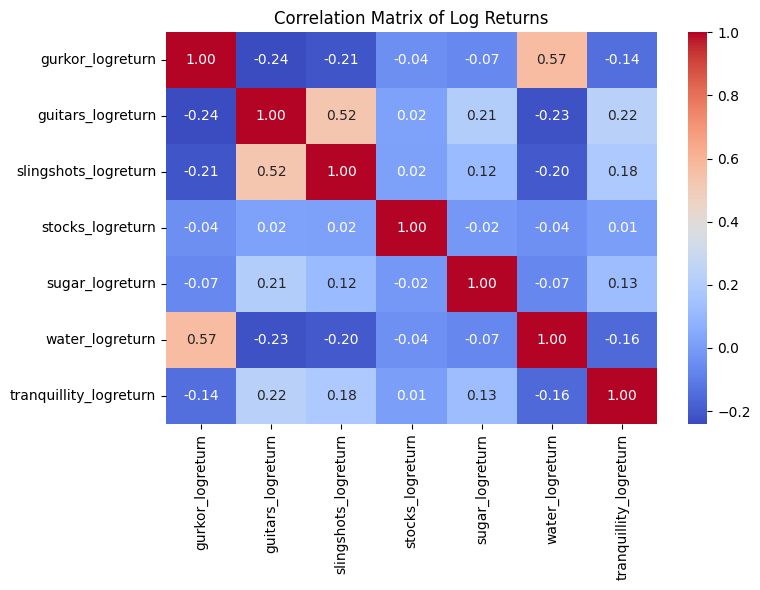

In [17]:
if "df_clean" not in globals():
    raise RuntimeError("Run the data loading cell first.")

corr_matrix = correlation_analysis(df_clean, min_periods=int(len(df_trunc) * 0.8))
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Log Returns")
plt.tight_layout()
plt.show()

The correlation matrix quantifies linear co-movement across assets.
- **Overall Portfolio Heterogeneity** <br>
Most pairs exhibit weak correlations in the range of [-0.2, 0.2], indicating low linear co-movement across the portfolio. However, this reflects only linear dependence, and tail co-movements during stress periods may be more pronounced and are not captured by this measure. Overall, the correlation structure suggests a relatively favorable diversification profile, with returns likely influenced by heterogeneous underlying drivers. 
- **Dominant positive cluster** <br>
The strongest linkages are guitars–slingshots (0.52) and gurkor–water (0.57), both moderate in magnitude. Their respective $R^2$ values of approximately 27% and 33% confirm that most variation is still asset-specific, indicating potential diversification benefits at the pair level.
- **Near-Zero Correlated "Anchors"** <br>
Stocks show near-zero correlation with all other assets ($\lt$ 0.04), indicating very weak linear co-movement within the portfolio. This suggests that stocks may provide diversification benefits in a multi-asset allocation by contributing relatively independent return variation in a linear sense.
- **Structural opposition between clusters.** <br>
Gurkor correlates positively with water (0.57) but negatively with guitars (-0.24) and slingshots (-0.21), while guitars and slingshots are mutually positively correlated (0.52). This suggests two loosely opposing clusters, {gurkor, water} vs. {guitars, slingshots} , offering natural hedging opportunities across clusters, though the moderate magnitudes limit the practical offset.

Note that correlation only reflects **average (time-invariant) linear dependence** and misses tail behavior. As a result, different assets may react very differently to the same event—some showing co-movement in the tails, others exhibiting isolated extremes—which is not captured by the correlation matrix.

In [20]:
df = pd.read_csv("./spiff_data-2.csv")
for col in val_cols:
    r = df_clean[col]
    valid = r.notna()
    group = (valid != valid.shift()).cumsum()
    price_series = pd.Series(index=r.index, dtype=float)
    asset = col.replace("_logreturn", "")
    for g in group[valid].unique():
            seg = r[group == g].dropna()
            idx = seg.index
            st = idx[0]
            
            # anchor price
            if st == r.index[0]:
                p0 = df[asset].iloc[0]
            else:
                p0 = df[asset].loc[st - 1]
            price_series.loc[idx] = p0 * np.exp(seg.cumsum())

    df_prices_clean[asset] = price_series


def compute_hurst(col, lags=None):
    s = col.to_numpy()

    if lags is None:
        max_lag = len(s) // 4
        if max_lag < 10:
            return np.nan
        lags = np.unique(np.floor(np.logspace(np.log10(10), np.log10(max_lag), 20)).astype(int))
    valid_lags, rs = [], []
    for lag in lags:
        chunks = [s[i:i+lag] for i in np.arange(0, len(s) - lag, lag)]
        rs_vals = []
        for chunk in chunks:
            if len(chunk) < 2: continue
            mean_adj = chunk - chunk.mean()
            cumdev   = np.cumsum(mean_adj)
            r        = cumdev.max() - cumdev.min()
            std      = chunk.std(ddof=1)     # unbiased
            if std > 0:
                rs_vals.append(r / std)
        if rs_vals:
            rs.append(np.mean(rs_vals))
            valid_lags.append(lag)

    if len(rs) < 2:
        return np.nan
    
    hurst, _ = np.polyfit(np.log(valid_lags), np.log(rs), 1)
    return hurst

def trend_autocorr(col, name, horizons=(5, 10, 20, 40), n_lags=1, min_periods=100):
    results = []
    for h in horizons:
        r_h = col.diff(h)
        for m in range(1, n_lags + 1):
            k = m * h
            df = pd.DataFrame({
                "r_h":     r_h,
                "r_h_lag": r_h.shift(k)
            }).dropna()
            if len(df) < min_periods:
                continue
            corr = df["r_h"].corr(df["r_h_lag"])
            results.append({"asset":name, "horizon": h, "lag_multiple": m, "corr": corr})
    if not results:
        return None, np.nan
    df_res = pd.DataFrame(results)
    return results, df_res["corr"]

summary = dict()
ac_results = []
for col in target_cols:
        col = col.replace("_logreturn", "")
        valid_interval = get_valid_segments_fixed(df_prices_clean[col])
        st, ed = max(valid_interval, key=lambda x: df_prices_clean[col].loc[x[0]:x[1]].shape[0])
        s = df_prices_clean[col].loc[st:ed]
        # 1. Hurst > 0.5 for trend persistence，～0.5 random walk, < 0.5 for mean-reverting
        # hurst = compute_hurst(np.log(s).diff().dropna())
        hurst = compute_hurst(np.log(s))

        # 2. trend autocorrelation on **log-price**, >0 Trend Persistence (Momentum)
        re, trend_ac = trend_autocorr(np.log(s), col)
        if re is not np.nan:
            ac_results.extend(re)  # extend not append
        trend_ac_mean = trend_ac.mean()
        summary[col] = {
            "hurst":        hurst,
            "trend_ac":     trend_ac_mean
        }
print(f"\n{'Asset':<12} {'Hurst':>10} {'Trend AC':>10}")
print("-" * 70)
for asset, stats in summary.items():
    print(f"{asset:<12} {stats['hurst']:>10.3f} {stats['trend_ac']:>10.3f}")



Asset             Hurst   Trend AC
----------------------------------------------------------------------
gurkor            1.008     -0.006
guitars           1.013      0.011
slingshots        1.006     -0.036
stocks            0.953     -0.016
sugar             1.011      0.017
water             1.019     -0.006
tranquillity      1.011      0.047


In [15]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df_clean.to_csv(OUTPUT_DIR / "df_clean_logreturns.csv")
df_prices_clean.to_csv(OUTPUT_DIR / "df_prices_clean.csv")

print("Saved cleaned log-returns and cleaned prices to outputs/")

Saved cleaned log-returns and cleaned prices to outputs/
